In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a = 2.46  # lattice constant Å
b1 = 2*np.pi/a * np.array([1, -1/np.sqrt(3)])
b2 = 2*np.pi/a * np.array([0, 2/np.sqrt(3)])

a1 = a * np.array([1, 0])
a2 = a * np.array([1/2, np.sqrt(3)/2])

k_max = 6 #A-1
kx = np.linspace(-k_max, k_max, 300)
ky = np.linspace(-k_max, k_max, 300)



def scattering_intensity(kx, ky, N_max):
    f = 0
    for Na in range(-N_max, N_max):
        for Nb in range(-N_max, N_max):
            R = Na * a1 + Nb * a2  
            dk = np.array([kx, ky])
            f += np.exp(1j * np.dot(dk, R)) 
    return np.square(np.abs(f))

def scattering_map(kx, ky, N_max):
    scattering_map = np.zeros((len(kx), len(ky)))
    for i, kx_val in enumerate(kx):
        for j, ky_val in enumerate(ky):
            scattering_map[i, j] = scattering_intensity(kx_val, ky_val, N_max)
    return scattering_map

def number_of_cells(N_max):
    return (2 * N_max+1) ** 2


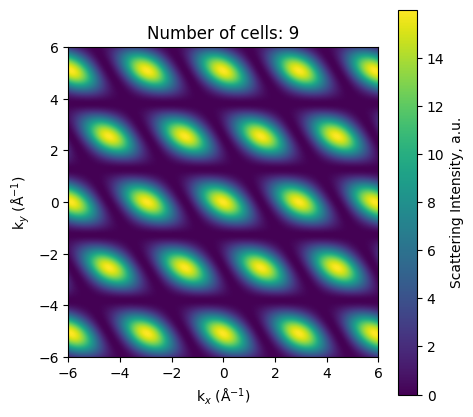

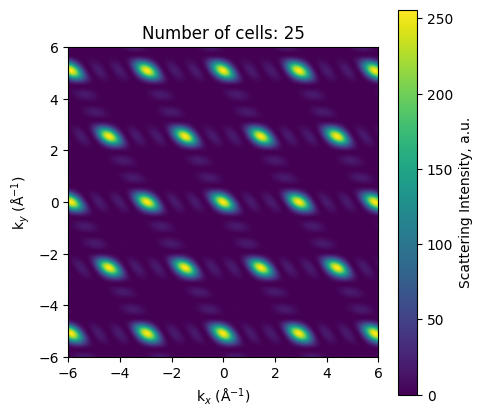

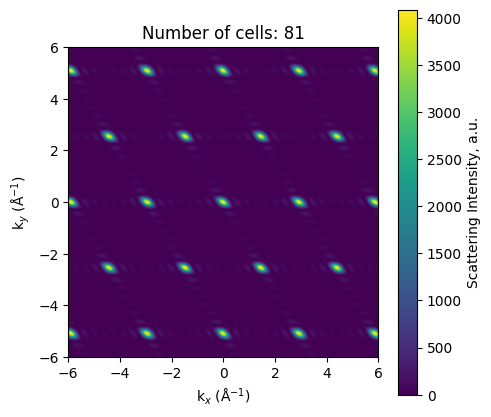

In [68]:

for N_max in [1, 2, 4]:
    vals = scattering_map(kx, ky, N_max)
    plt.figure(figsize=(5,5))
    plt.imshow(vals, extent=[-k_max, k_max, -k_max, k_max], origin='lower')
    plt.xlabel('k$_x$ (Å$^{-1}$)')
    plt.ylabel('k$_y$ (Å$^{-1}$)')
    plt.title(f'Number of cells: {number_of_cells(N_max)}')
    plt.colorbar(label='Scattering Intensity, a.u.')
    plt.show()